# Lasso Regression from Scratch 🎯

In this notebook, we implement **Lasso Regression**, which uses **L1 Regularization** to create sparse models.

## 📖 Theoretical Background

Unlike Ridge (L2), Lasso (Least Absolute Shrinkage and Selection Operator) penalizes the absolute magnitude of the coefficients, which can shrink some coefficients exactly to zero, performing feature selection.

### 1. The Cost Function
$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2 + \lambda \sum_{j=1}^{n} |w_j|$$

### 2. Coordinate Descent
The L1 penalty is not differentiable at $w_j = 0$, so standard Gradient Descent struggles. Instead, we use **Coordinate Descent**, optimizing one feature coordinate at a time while holding others fixed.

For normalized data, the update rule for weight $w_j$ uses the **Soft Thresholding** operator:
$$w_j = \text{soft\_threshold}(\rho_j, \lambda) = \text{sign}(\rho_j) \max(|\rho_j| - \lambda, 0)$$
Where $\rho_j$ is the correlation between the feature $j$ and the residual (excluding feature $j$).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

np.random.seed(42)

## 🏗️ The Implementation

In [2]:
class LassoRegression:
    def __init__(self, lambda_param=1.0, n_iterations=1000):
        self.lambda_param = lambda_param
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
        
    def _soft_threshold(self, rho, lamda):
        if rho < -lamda:
            return rho + lamda
        elif rho > lamda:
            return rho - lamda
        else:
            return 0.0
            
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        
        # Pre-compute sum of squares for each feature to normalize rho
        z = np.sum(X**2, axis=0)
        
        for _ in range(self.n_iterations):
            # Update bias
            self.b = np.sum(y - np.dot(X, self.w)) / n_samples
            
            # Update weights via Coordinate Descent
            for j in range(n_features):
                # Calculate residual without feature j
                w_temp = self.w.copy()
                w_temp[j] = 0.0
                y_pred_no_j = np.dot(X, w_temp) + self.b
                
                rho_j = np.sum(X[:, j] * (y - y_pred_no_j))
                
                if z[j] == 0:
                    self.w[j] = 0
                else:
                    self.w[j] = self._soft_threshold(rho_j, self.lambda_param * n_samples) / z[j]
                    
    def predict(self, X):
        return np.dot(X, self.w) + self.b

## 🧪 Data Generation and Training
We generate data with 10 features, but only 2 are informative. Lasso should shrink the useless ones to zero.

In [3]:
X, y, true_coef = make_regression(n_samples=200, n_features=10, n_informative=2, noise=10, coef=True, random_state=42)

model = LassoRegression(lambda_param=20.0, n_iterations=500)
model.fit(X, y)

print("True Coefficients:\n", np.round(true_coef, 2))
print("\nLasso Coefficients:\n", np.round(model.w, 2))

True Coefficients:
 [ 0.    0.    0.    0.    0.    0.    6.6  40.71  0.    0.  ]

Lasso Coefficients:
 [ 0.    0.    0.    0.    0.    0.    0.   14.66  0.    0.  ]


## 📊 Visualization

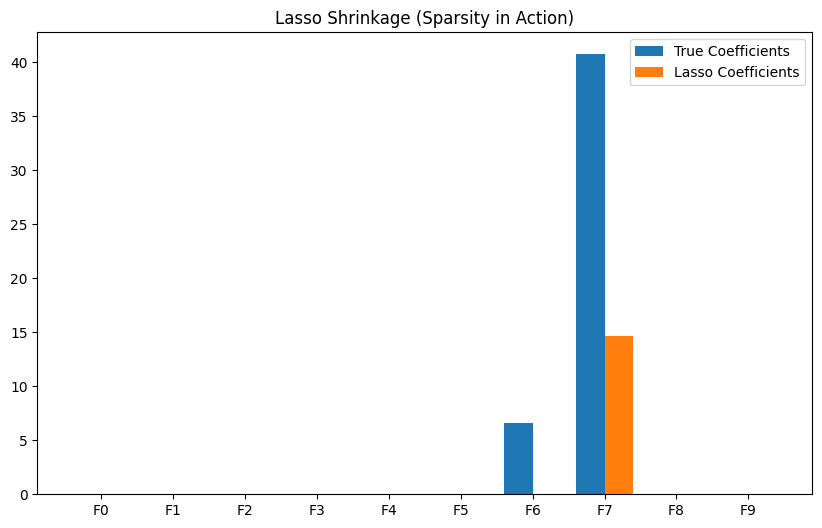

In [4]:
plt.figure(figsize=(10, 6))
features = np.arange(len(model.w))
width = 0.4

plt.bar(features - width/2, true_coef, width, label='True Coefficients')
plt.bar(features + width/2, model.w, width, label='Lasso Coefficients')

plt.xticks(features, [f"F{i}" for i in features])
plt.title("Lasso Shrinkage (Sparsity in Action)")
plt.legend()
plt.show()

## 📊 Additional Visualizations

In [ ]:

# 1. Lasso Coefficients Path
alphas = np.logspace(-2, 2, 20)
coefs = []
for a in alphas:
    temp_model = LassoRegression(alpha=a)
    temp_model.fit(X, y)
    coefs.append(temp_model.weights)

plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Weights')
plt.title('Lasso Coefficients as a function of regularization')
plt.show()
